<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Spring_2026/blob/main/Module%206/Final_Active_Experimental_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Active Experimental Design under Noise and Budget Constraints

In many experiments we aim to discover how a property depends on composition or processing conditions. This is often a case for characterization by XRD, SPM, Raman etc. of spread combinatorial libraries, where a continuous range of compositions is explored on a single substrate.

A mainstream approach for automating such experiments is Bayesian optimization (BO), where a surrogate model (e.g. Gaussian process) is used to predict the property and guide the selection of the next measurement in an active, closed-loop manner.

However, classical BO typically assumes idealized conditions and does not explicitly account for key experimental constraints, such as:

- measurement noise that depends on acquisition time,
- limited experimental budget,
- and cost of moving between measurement locations.

In this challenge, the goal is to design a strategy that, using a surrogate model, decides:

- **where to measure**,
- **in what order**,
- and **for how long**,

in order to efficiently explore and recover the underlying functional dependence under these realistic conditions.

###gif_Classical BO with GP surrogate model



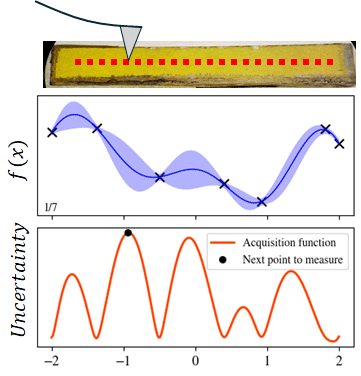

## Functions

In [ ]:
!pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 8.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

In [ ]:
#@title target function

# F1 — Smooth unimodal
def unimodal(x):
    x = np.asarray(x)
    res = 0.15 * (x + 2)**2 + 0.03 * (x - 1)**4
    return res/20


# F2 — Double-well
def double_well(x):
    x = np.asarray(x)
    res = 0.08 * (x**2 - 4)**2 + 0.15 * x

    return res/10


# F3 — Multimodal (Rastrigin-like, 1D)
def multimodal(x):
    x = np.asarray(x)
    res = 10 + x**2 - 7 * np.cos(2 * np.pi * x) + 9 * np.sin(1.4 * np.pi * x)
    return res/40


# F4 — Broad + narrow minima
def broad_narrow(x):
    x = np.asarray(x)

    res = (
        1
        - 1.0 * np.exp(-((x + 1.5)**2) / (2 * 0.9**2))
        - 1.6 * np.exp(-((x - 1.0)**2) / (2 * 0.18**2))
    )
    return res

In [ ]:
#@title simple noise models

def noise_constant(x = None, t = None, sigma0=0.1):
    t = np.asarray(t)
    return sigma0 * np.ones_like(t, dtype=float)

def noise_decay_floor(x = None, t = None, sigma_min=0.05, A=0.18, tau=1.0):
    t = np.asarray(t)
    return sigma_min + A * np.exp(-t / tau)

In [ ]:
#@title heteroskedastic_noise_model

def make_heteroskedastic_noise_model(f, xlim, n_grid=200, smooth_window=3):
    """
    Build heteroskedastic noise model on a fixed domain.

    Parameters
    ----------
    f : callable
        Ground truth function
    xlim : tuple (xmin, xmax)
        Domain of interest
    """

    xmin, xmax = xlim
    x_grid = np.linspace(xmin, xmax, n_grid)
    y_grid = f(x_grid)

    # gradient
    grad = np.abs(np.gradient(y_grid, x_grid, edge_order=2))

    # smoothing
    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        half = smooth_window // 2
        grad_s = np.pad(grad, pad_width=half, mode="reflect")
        grad = np.convolve(grad_s, kernel, mode="valid")

    # normalization
    scale = np.percentile(grad, 95) + 1e-12
    grad_norm_grid = grad / scale

    def noise_model(x, t, sigma_min=0.05, sigma_max=0.5, tau=1.5):
        x = np.asarray(x, dtype=float)
        t = np.asarray(t, dtype=float)

        g = np.interp(x, x_grid, grad_norm_grid)
        sigma0_x = sigma_min + (sigma_max - sigma_min) * g

        return sigma_min + (sigma0_x - sigma_min) * np.exp(-t / tau)

    return noise_model

In [ ]:
#@title measurement simulator

class MeasurementSimulator:
    def __init__(self, ground_truth_model, noise_model, rng=None, **noise_kwargs):
        """
        Parameters
        ----------
        ground_truth_model : callable
            Function f(x)
        noise_model : callable
            Function sigma(x, t, **noise_kwargs)
        rng : None, int, or np.random.Generator
            Random generator or seed
        **noise_kwargs
            Default parameters for noise_model
        """
        self.f = ground_truth_model
        self.noise_model = noise_model
        self.noise_kwargs = noise_kwargs

        if rng is None:
            self.rng = np.random.default_rng()
        elif isinstance(rng, (int, np.integer)):
            self.rng = np.random.default_rng(rng)
        else:
            self.rng = rng

    def measure(self, coords, **noise_kwargs):
        """
        coords : array of shape (N, 2)
            Columns are (x, t)

        Returns
        -------
        y_meas : array of shape (N,)
            Noisy measurements
        """
        coords = np.asarray(coords, dtype=float)

        if coords.ndim != 2 or coords.shape[1] != 2:
            raise ValueError("coords must have shape (N, 2)")

        x = coords[:, 0]
        t = coords[:, 1]

        kwargs = {**self.noise_kwargs, **noise_kwargs}
        sigma = np.asarray(self.noise_model(x, t, **kwargs), dtype=float)
        noise = self.rng.normal(0.0, sigma, size=len(x))

        return self.f(x) + noise

    __call__ = measure

In [ ]:
#@title gp functions

import torch
import gpytorch


def gp_predict(x_train, y_train, x_test, training_iter=100, lr=0.1):
    """
    Fit GP on (x_train, y_train) and predict on x_test.

    Parameters
    ----------
    x_train : array-like (N,)
    y_train : array-like (N,)
    x_test  : array-like (M,)

    Returns
    -------
    mean : (M,)
    std  : (M,)
    """

    # convert to torch
    x_train = torch.as_tensor(x_train, dtype=torch.float32)
    y_train = torch.as_tensor(y_train, dtype=torch.float32)
    x_test  = torch.as_tensor(x_test, dtype=torch.float32)

    # ensure 2D inputs
    if x_train.ndim == 1:
        x_train = x_train.unsqueeze(-1)
    if x_test.ndim == 1:
        x_test = x_test.unsqueeze(-1)

    # define model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()

    class GPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super().__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.RBFKernel()
            )

        def forward(self, x):
            mean = self.mean_module(x)
            covar = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean, covar)

    model = GPModel(x_train, y_train, likelihood)

    # train
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for _ in range(training_iter):
        optimizer.zero_grad()
        output = model(x_train)
        loss = -mll(output, y_train)
        loss.backward()
        optimizer.step()

    # predict
    model.eval()
    likelihood.eval()

    with torch.no_grad():
        pred = likelihood(model(x_test))
        mean = pred.mean.cpu().numpy()
        std = pred.stddev.cpu().numpy()

    return mean, std

In [ ]:
#@title cost models

def travel_cost(dx, speed=0.5) -> float:
  return abs(dx) / speed


## Introduction

In [ ]:
x = np.linspace(-4,4,100) #spatial coordinate (compositional/parameter space)
t = np.linspace(0,10,100) #acquisition time

We suggest selecting one of the following four “ground truth” functions to represent the underlying functionality.

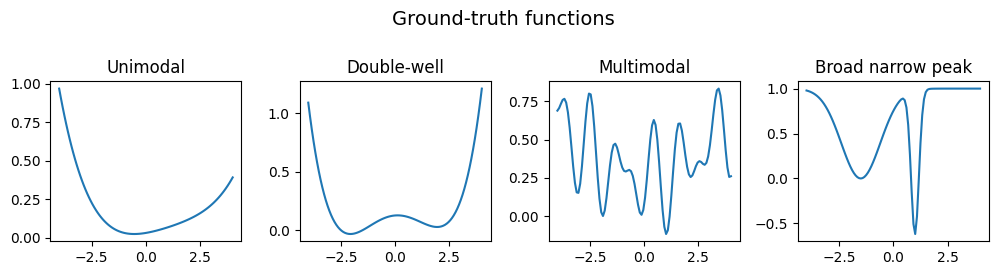

In [ ]:
#ground truth functions
fig, ax = plt.subplots(1,4, figsize=(10, 2.7))

ax[0].plot(x, unimodal(x))
ax[1].plot(x, double_well(x))
ax[2].plot(x, multimodal(x))
ax[3].plot(x, broad_narrow(x))

ax[0].set_title('Unimodal')
ax[1].set_title('Double-well')
ax[2].set_title('Multimodal')
ax[3].set_title('Broad narrow peak')

fig.suptitle('Ground-truth functions', y=1, fontsize=14)

plt.tight_layout()

To emulate noisy measurements, we consider two homoscedastic noise models. The first is a **constant noise** model (trivial case), where the measurement precision is independent of acquisition time. The second is a **decaying noise** model, where the noise decreases exponentially with acquisition time and approaches a maximum achievable precision.

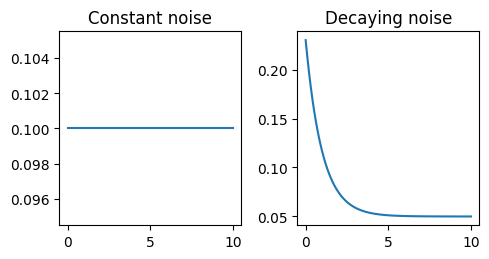

In [ ]:
#homoskedastic noise model

fig, ax = plt.subplots(1,2, figsize=(5, 2.7))

ax[0].plot(t, noise_constant(x, t))
ax[0].set_title('Constant noise')
ax[1].plot(t, noise_decay_floor(x, t))
ax[1].set_title('Decaying noise')

plt.tight_layout()

For those seeking more hardcore challenge, we also suggest a **heteroscedastic noise model**, where the measurement noise depends on the location. In our specific case, the noise level is proportional to the local gradient of the underlying function, while still decaying with acquisition time toward a limiting precision.

Text(0.5, 0.98, 'Heteroskedastic noise model')

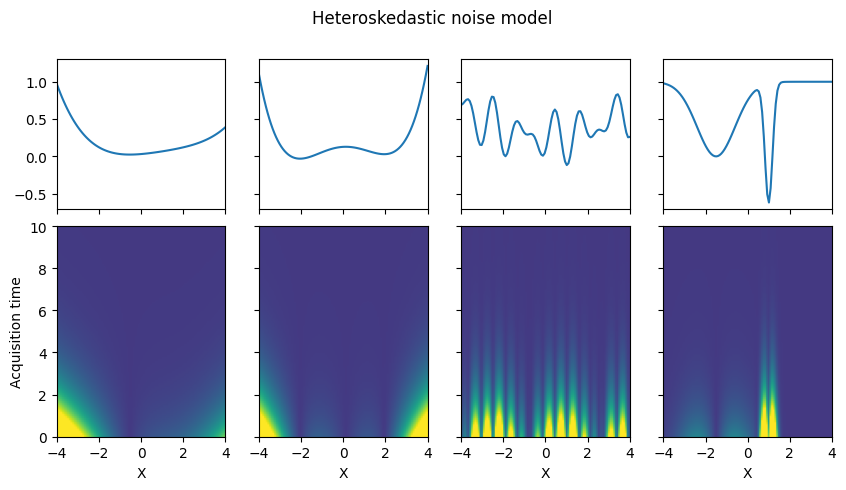

In [ ]:
#@title heteroskedastic noise model

funcs = [unimodal, double_well, multimodal, broad_narrow]

fig, ax = plt.subplots(2, 4, figsize=(10, 5),
                       height_ratios=(1,1.5),
                       sharex=True,
                       sharey='row',
                       gridspec_kw={'hspace': 0.05})

for i,ax0_ in enumerate(ax[0]):
  ax0_.plot(x, funcs[i](x))

for i,ax1_ in enumerate(ax[1]):
  noise_model = make_heteroskedastic_noise_model(funcs[i], (-4, 4))
  ax1_.imshow(noise_model(x, t.reshape(-1,1)),
              origin='lower',
              extent=[x.min(), x.max(), t.min(), t.max()],
              vmax=.3, vmin=0)
  ax1_.set_xlabel('X')

ax[1,0].set_ylabel('Acquisition time')

fig.suptitle('Heteroskedastic noise model')


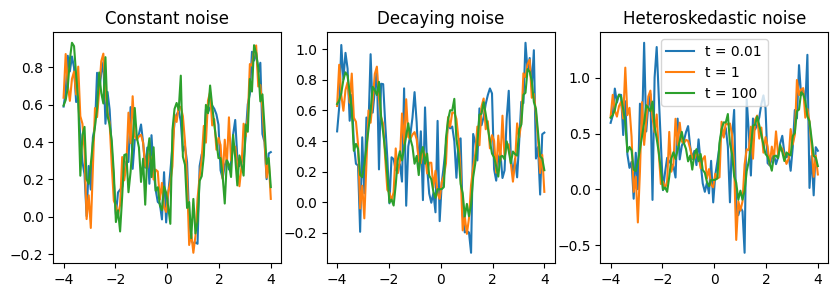

In [ ]:
#@title example: grid measurements with different acqusition time

x = np.linspace(-4,4, 100) #x grid

durations = [0.01, 1, 100] #select durations
model = multimodal #select model [unimodal, double_well, multimodal, broad_narrow]

noise_heter_model = make_heteroskedastic_noise_model(model, (-4, 4))

sim_const = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_constant,
    rng=123,
)

sim_decay = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_decay_floor,
    rng=123,
)

sim_heterosk = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_heter_model,
    rng=123,
)

fig, ax = plt.subplots(1, 3, figsize=(10,3))

for d in durations:
  d_ar = np.ones(len(x))*d
  coords = np.vstack([x, d_ar]).T

  ax[0].plot(coords[:,0], sim_const.measure(coords), label = f't = {d}')
  ax[1].plot(coords[:,0], sim_decay.measure(coords), label = f't = {d}')
  ax[2].plot(coords[:,0], sim_heterosk.measure(coords), label = f't = {d}')

ax[0].set_title('Constant noise')
ax[1].set_title('Decaying noise')
ax[2].set_title('Heteroskedastic noise')
ax[2].legend()

In [ ]:
#@title example: surrogate modeling

#homoskedatic noise model: [noise_constant, noise_decay_floor]
#ground truth models: [unimodal, double_well, multimodal, broad_narrow]


#If we select the heteroskedastic noise model, we first need to construct it. For the homoskedastic cases, the models are already defined.
noise_heter_model = make_heteroskedastic_noise_model(double_well, xlim=(-4, 4)) #please define the x range

meas_sim = MeasurementSimulator(
    ground_truth_model=double_well,
    noise_model=noise_heter_model,
    rng=123,
)

In [ ]:

#define x_grid on the explored interval

x_grid = np.linspace(-4, 4, 500)

# For this example, select 4 random locations in the range (-4, 4)
x = np.random.random(7) * 8 - 4

# Set acquisition time (t = 3) for all locations
t = np.ones(len(x)) * 1

# Form the coordinate array: [[x1, t1], [x2, t2], ...]
coords = np.column_stack([x, t])

#make "measurements"
y = meas_sim.measure(coords)

#surrogate modeling
mean, std = gp_predict(x, y, x_grid, training_iter=100, lr=0.1)

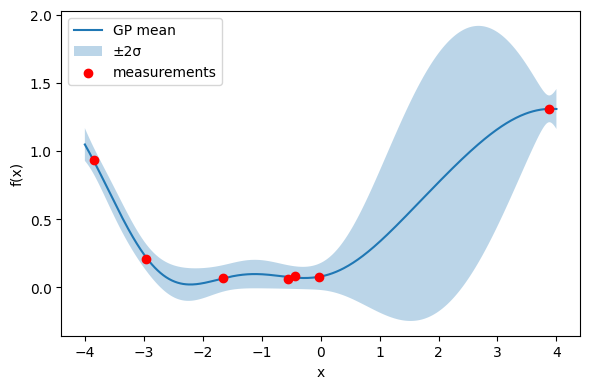

In [ ]:
plt.figure(figsize=(6, 4))

# GP mean
plt.plot(x_grid, mean, label="GP mean")

# uncertainty band
plt.fill_between(
  x_grid,
  mean - 2 * std,
  mean + 2 * std,
  alpha=0.3,
  label="±2σ"
)

# training points
plt.scatter(x, y, color="red", zorder=3, label="measurements")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()
plt.show()

For simplicity, we treat time as the cost function. The cost of a single measurement is therefore equal to its acquisition time. In addition, we introduce a travel cost, which accounts for moving between measurement locations and is assumed to be proportional to the distance between them.

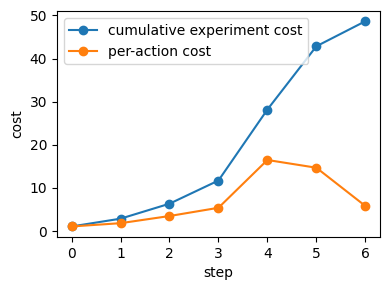

In [ ]:
#@title total experiment cost

# initial position
x0 = 0

# displacement between consecutive points (including first move from x0)
dx = x - np.append(x0, x[:-1])

# cost of each action = travel cost + acquisition time
action_costs = travel_cost(dx) + t

# visualize costs
fig = plt.figure(figsize=(4,3))
plt.plot(np.cumsum(action_costs), 'o-', label='cumulative experiment cost')
plt.plot(action_costs, 'o-', label='per-action cost')

plt.xlabel('step')
plt.ylabel('cost')
plt.legend()
plt.tight_layout()




---


## Final
---



### Part I

Part I. First, let's make sure that there is indeed a problem. Assume that total experimental time is 80, an dmoving form one location to another takes 5 time units (and does not depend on the measurement distance). Here, if we do measurement with just one location, we have low noise, but we definitely have not learned ur function f(x). At the same time, if we do measurement at 16 locations, all out time is spent moving. So the optimum is somewhere between.

You are free to choose the ground truth function and noise model (decaying or heteroskedastic, use constant noise only for benchmarking if needed).

In [ ]:
B = 80 #your budget (can be different)

meas_sim = MeasurementSimulator(
    ground_truth_model=double_well, #choose gt function
    noise_model=noise_decay_floor,  #choose noise model
    rng=123,
)

I.1. First, experiment with the simple gird search. Let's assume that we run measurements at N = 1, 2, 3, .. , 16 points. How does MSE error and predictive uncertaity change with N? WHat is optimal time?

I.2. Now let's assume that you run this as a Bayesian Optimization cycle for fixed duration. Make the same estimate

I.3. Now asusme that the cost of mocing is proportional to the travelled length. Explore how BO works in this case.

### Part II

Design a strategy that selects where to measure, in what order, and for how long, using the provided simulator and a fixed total budget. The objective is to reconstruct or optimize an unknown function as efficiently as possible under noisy measurements and movement cost. Implement and compare two different approaches for solving open decision making problem. You can choose from:

1. Dynamic Programming: plan actions by optimizing expected future rewards and costs over a finite horizon

2. Reinforcement Learning: learn a policy through interaction with the simulator

3. Value Function (surrogate/BO): select actions based on immediate utility (e.g., uncertainty or acquisition function)

4. Lookahed policy

5. ... and so on

Hint: brainstorm the overall problem with ChatGPT, and explore different possible startegies. Please pay specific attention to what is used to make decisions, and what should be experimental budget (i.e. how does the algorithm learn).

Each method must decide where to measure and how long (cost–noise trade-off). Plot exploration trajectory, cost for measurement/moving along the experimental cmapaign, and monitoring functions (e.g. value function for (x,t)). Evaluate performance in terms of reconstruction accuracy and budget efficiency. What advantage do we get compared to grid and myopic policies?







Method A

Explanation:

In [ ]:
#realization

In [ ]:
#metrics

Method B

Explanation

In [ ]:
#realization

In [ ]:
#metrics

Do you expect your algorithm to be transferable to a different scenario (e.g. function with maximum in different location) and what wuld it require?

Explanation